# Urban Mobility Analysis in Latin America

---
#  1. Project Overview

Traffic congestion is one of the main challenges faced by large cities in Latin America, affecting economic productivity, environmental sustainability, and quality of life.

This project analyzes urban mobility indicators alongside economic data to explore the relationship between traffic congestion and economic performance across major Latin American cities.

## Business Objective

The objective of this project is to identify mobility patterns, evaluate their relationship with economic indicators, and generate insights that can support urban planning and transportation policy decisions.

## Data Sources

- TomTom Traffic Index
- OECD City Economy Dataset

## Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook



---
# 2. Data Loading

## Purpose

This section imports the Python libraries required for data manipulation, analysis, and visualization. It also prepares the working environment to load and process the datasets used throughout the project.

### Libraries Used

- **Pandas**: data manipulation and analysis.
- **NumPy**: numerical computations.
- **Matplotlib**: data visualization.

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

---
# 3. Load Datasets

The analysis combines two complementary datasets that provide information about urban mobility and economic performance across Latin American cities.

### Dataset 1: TomTom Traffic Index

This dataset contains traffic congestion indicators for major cities, allowing the evaluation of mobility conditions.

### Dataset 2: OECD City Economy Dataset

This dataset provides economic indicators that help analyze the relationship between urban mobility and economic performance.

Both datasets are loaded into pandas DataFrames for subsequent cleaning, transformation, and analysis.

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

---
# 4. Data Understanding

Before preparing the data, an initial assessment is performed to understand the structure, quality, and characteristics of each dataset.

The objective of this stage is to identify potential issues that could affect the analysis and determine the preprocessing steps required.

The assessment includes:

## Dataset Structure

- Number of observations
- Number of variables

## Data Types

- Numerical variables
- Categorical variables
- Date variables

## Data Quality

- Missing values
- Duplicate records
- Inconsistent values

## Descriptive Statistics

Summary statistics are reviewed to understand the distribution and variability of the numerical variables.


## 4.1 Data Quality Assessment

In [ ]:
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

# 5.  Data Preparation

### Inspect Dataset Structure

The `.info()` method is used to verify the number of observations, variable names, data types, and missing values in each dataset before performing any transformations.


In [ ]:
# Inspect Dataset Structure
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [ ]:
# Inspect Dataset Structure
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


### 5.1 Rename Columns

## Purpose

To improve readability and maintain consistency throughout the analysis, column names are standardized using lowercase letters and descriptive names.

Standardized column names make the code easier to understand, reduce the likelihood of errors, and simplify future data processing tasks.

In [ ]:
### Standardize Mobility Dataset Columns

####The original column names are renamed to follow a consistent naming convention using lowercase letters and underscores.
traffic = traffic.rename(columns={
    "Country": "country",
    'City':'city',
    "UpdateTimeUTC": "update_time_utc",
    "UpdateTimeUTCWeekAgo":"update_time_utc_week_ago",
     'JamsDelay':'jams_delay',
    'TrafficIndexLive':'traffic_index_live',
    'JamsLengthInKms':"jams_length_kms",
    'JamsCount':"jams_count",
    'TravelTimeLivePer10KmsMins':"travel_time_live_per_10kms_mins",
       'TravelTimeHistoricPer10KmsMins':"travel_time_hist_per_10kms_mins",
    'MinsDelay':"mins_delay"
})

### Verify Updated Column Names
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'TrafficIndexWeekAgo', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
### Standardize Economic Dataset Columns

###The economic dataset is also standardized to ensure compatibility when both datasets are merged later in the analysis.
eco = eco.rename(columns={
    "Year":"year",
    'City':'city',
    'Country':'country',
    "City GDP/capita": "city_gdp_capita",
    "Unemployment %": "unemployment_pct",
    "Population (M)": "population_m",
    'PM2.5 (μg/m³)':'pm25'
})
### Verify Updated Column Names
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

## 5.2 Data Type Conversion

## Purpose

After standardizing the column names, the next step is to ensure that each variable has the appropriate data type.

Correct data types are essential for accurate calculations, filtering, grouping, date operations, and visualizations. During this stage, numerical values and date fields are converted to formats suitable for analysis.


In [ ]:
### Convert Date Variables

## Date columns are converted to the appropriate datetime format to enable time-based analysis and feature extraction.
traffic['update_time_utc'] = pd.to_datetime(traffic["update_time_utc"], errors="coerce")
traffic["update_time_utc_week_ago"] = pd.to_datetime(traffic["update_time_utc_week_ago"], errors="coerce")


### Validate Data Types

### The updated data types are reviewed to verify that each variable has been converted successfully before continuing with the analysis.
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   TrafficIndexWeekAgo              1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [ ]:
### Convert Numeric Variables

### Some variables were imported as text due to formatting differences (for example, decimal separators or special characters). These columns are converted to numeric values to enable statistical analysis.
eco["city_gdp_capita"] = eco["city_gdp_capita"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)
eco["unemployment_pct"] = eco["unemployment_pct"].str.replace("%", "", regex=False).str.replace(",", ".", regex=False).astype(float)
eco["population_m"] = eco["population_m"].str.replace(",", ".", regex=False).astype(float)


# population in absolute units
eco["population"] = eco["population_m"] * 1000000

### Validate Data Types

### The updated data types are reviewed to verify that each variable has been converted successfully before continuing with the analysis.
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


---

# 6. Feature Engineering

## Purpose

Feature engineering consists of creating or transforming variables to make the data more useful for analysis.

In this project, new features are generated to facilitate comparisons between datasets and support the analysis of mobility and economic indicators across cities.

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

## 6.1 Extract Year

The year is extracted from the date column to enable temporal filtering and ensure that both datasets are aligned for comparison.

This step simplifies time-based analysis and supports the integration of mobility and economic information.


In [ ]:
### Validate Extracted Year

### The newly created year variable is reviewed to confirm that it was generated correctly.
traffic["year"] = traffic["update_time_utc"].dt.year

traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,TrafficIndexWeekAgo,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


## 6.2 Filter Relevant Data

Only the records relevant to the scope of this project are retained.

Filtering the data ensures consistency between datasets and focuses the analysis on the selected time period.

In [ ]:
### Validate Filtered Data

### The filtered dataset is reviewed to verify that only the intended records remain.
traffic_2024 = traffic[traffic["year"] == 2024].copy()
eco_2024 = eco[eco["year"] == 2024].copy()

display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,TrafficIndexWeekAgo,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

# 7. Mobility Data Analysis
## 7.1 Aggregate Mobility Indicators

### Business Objective

The traffic dataset contains multiple observations for each city. To facilitate comparisons and prepare the data for integration with the economic dataset, the mobility indicators are aggregated by city, country, and year.

The average values provide a representative measure of traffic conditions for each city during the selected period.

In [ ]:
# Aggregate mobility indicators by city, country, and year
# using the mean value of each traffic metric.
traffic_city_year_2024 = (
    traffic_2024
    .groupby(["city", "country", "year"], as_index=False)[
        [
            "jams_delay",
            "traffic_index_live",
            "jams_length_kms",
            "jams_count",
            "mins_delay",
            "travel_time_live_per_10kms_mins",
            "travel_time_hist_per_10kms_mins"
        ]
    ]
    .mean()
)


traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### Validate Aggregated Dataset

The resulting dataset is reviewed to confirm that each city has a single aggregated record containing the average mobility indicators.

This dataset will be used in the following steps for integration with the economic information.

## 7.2 Rank Cities by Average Traffic Delay

### Business Question

Which cities experience the highest average traffic delays?

Ranking cities by average traffic delay helps identify the locations most affected by congestion and provides an initial view of where mobility challenges are more severe.

The dataset is sorted in descending order based on the average traffic delay (`jams_delay`).

In [ ]:
# Rank cities from highest to lowest average traffic delay
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


### Interpretation

The ranking highlights the cities with the highest average traffic delays.

These cities represent potential priority areas for improving transportation infrastructure, optimizing traffic management, or implementing mobility policies aimed at reducing congestion.


---
# 8. Data Integration

## Business Objective

To understand the relationship between urban mobility and economic conditions, the mobility and economic datasets are combined into a single analytical dataset.

This integration enables the comparison of traffic indicators with socioeconomic variables such as GDP per capita, unemployment rate, air quality, and population.

The resulting dataset serves as the foundation for the exploratory analysis presented in the next section.


## 8.1 Select Relevant Variables

Only the variables required for the analysis are selected from each dataset.

Reducing the number of columns improves readability, simplifies the merge process, and focuses the analysis on the variables that contribute to answering the business question.

Independent copies of the selected variables are created to preserve the original datasets and avoid unintended modifications during the analysis.

## 8.2 Merge Mobility and Economic Data

The mobility and economic datasets are merged using the common identifiers:

- City
- Year

An **inner join** is applied to retain only the observations that exist in both datasets, ensuring consistency in the subsequent analysis.

### Validate Merged Dataset

The merged dataset is reviewed to verify that the integration was successful and that the selected variables are available for analysis.

The first records are displayed to confirm the structure of the resulting DataFrame.

In [ ]:
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

## Create Analysis Datasets

traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Merge mobility and economic datasets using city and year
merged = pd.merge(
    traffic_2024_small,
    eco_2024_small,
    on=["city", "year"],
    how="inner"
)

#Validate Merged Dataset
display(merged.head(5))

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


## Integration Summary

The integration process successfully combines mobility and economic indicators into a single analytical dataset.

This unified dataset enables the exploration of relationships between traffic congestion, economic performance, population, unemployment, and environmental factors, providing the foundation for the exploratory data analysis.

---
# 9. Exploratory Data Analysis (EDA)

## Purpose

The objective of this section is to explore the relationship between urban mobility and economic indicators across major Latin American cities.

Through visual analysis, patterns, variability, and potential relationships between traffic congestion and economic performance are identified.

## 9.1 Distribution of Traffic Congestion

### Business Question

How is traffic congestion distributed across the analyzed cities?

The boxplot summarizes the distribution of average traffic delays, highlighting the median, variability, mean value, and potential outliers.

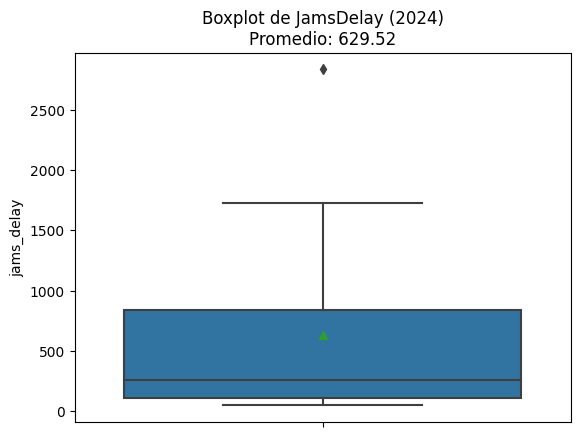

In [ ]:
# The boxplot
sns.boxplot(data=merged, y="jams_delay", showmeans=True)

# average traffic delays
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


### Interpretation

The boxplot shows that traffic congestion varies considerably across the analyzed cities.

Most cities present relatively moderate congestion levels, while a small number of cities exhibit substantially higher average delays, appearing as outliers.

The difference between the median and the mean suggests that high-congestion cities increase the overall average, indicating an asymmetric distribution.

## 9.2 Distribution of GDP per Capita

### Business Question

How is economic performance distributed across the analyzed cities?

The histogram illustrates the distribution of GDP per capita, allowing the identification of concentration ranges and potential extreme values.

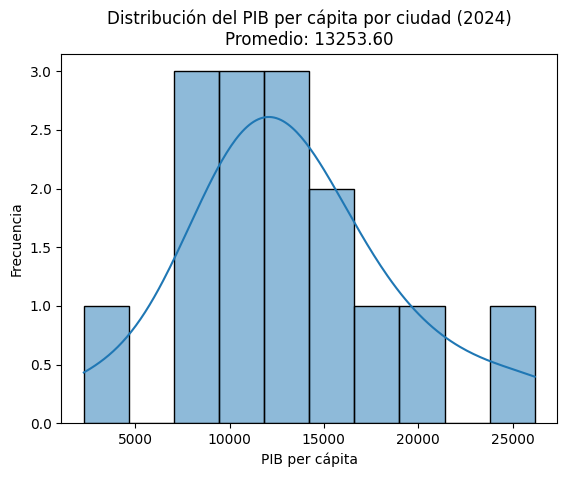

In [ ]:
# The histogram illustrates the distribution of GDP per capita
sns.histplot(data=merged, x="city_gdp_capita", bins=10, kde=True)

mean_gdp = merged["city_gdp_capita"].mean()
plt.title(f"Distribución del PIB per cápita por ciudad (2024)\nPromedio: {mean_gdp:.2f}")
plt.xlabel("PIB per cápita")
plt.ylabel("Frecuencia")
plt.show()


### Interpretation

Most cities are concentrated within the middle GDP per capita range, while only a few cities present considerably higher economic performance.

The distribution suggests moderate variability in economic conditions across the selected cities.

## 9.3 Mobility and Economic Comparison

### Business Question

How do traffic congestion and GDP per capita vary across the analyzed cities?

The following visualization compares both indicators for each city, providing an initial overview before investigating possible relationships.

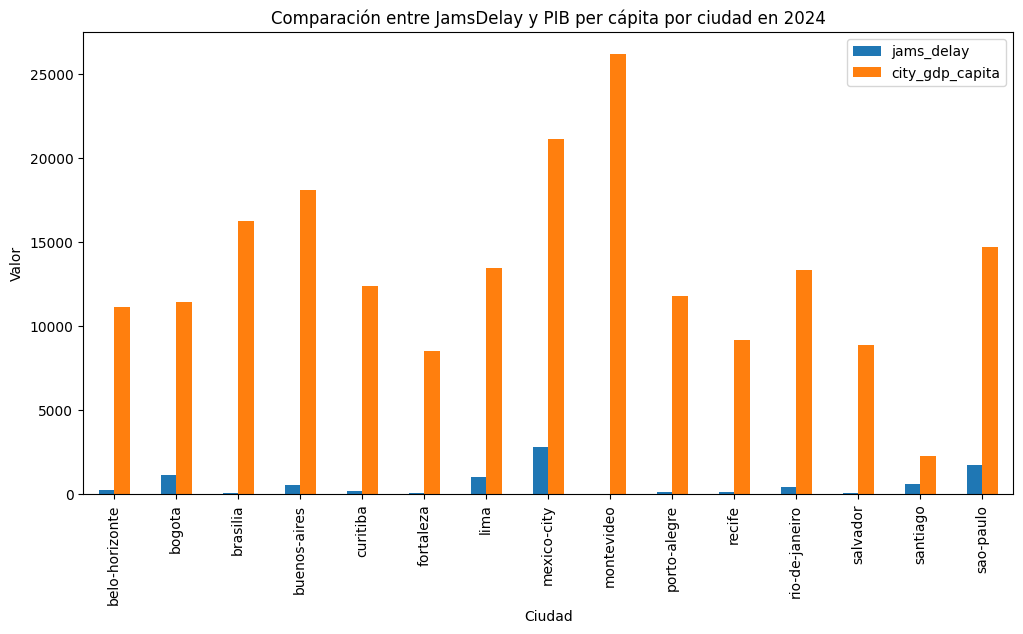

In [ ]:
# Visualization compares both indicators for each city
merged.plot(
    x="city",
    y=["jams_delay", "city_gdp_capita"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparación entre JamsDelay y PIB per cápita por ciudad en 2024")
plt.xlabel("Ciudad")
plt.ylabel("Valor")
plt.xticks(rotation=90)

plt.show()

### Interpretation

The comparison shows that cities with higher GDP per capita do not always exhibit higher or lower traffic congestion.

Although differences between cities are evident, the visualization alone does not indicate a clear relationship between economic performance and congestion levels.

A more appropriate analysis would require a scatter plot or correlation analysis.

---
# 10. Key Insights

The exploratory analysis produced the following initial findings:

- Traffic congestion varies considerably across the analyzed cities, with a small number of cities exhibiting substantially higher average traffic delays than the rest.

- Mexico City presents the highest average traffic delay among the analyzed cities, indicating particularly severe congestion conditions.

- GDP per capita shows moderate variability across cities; however, higher economic performance is not consistently associated with either higher or lower congestion levels.

- The visual comparison between traffic and economic indicators suggests that the relationship between congestion and GDP per capita is weak, indicating that additional factors may explain differences in urban mobility.



---
# 11. Conclusions

The analysis explored the relationship between urban mobility indicators and economic performance across 15 Latin American cities during 2024.

The results indicate that no clear relationship exists between GDP per capita and traffic congestion. Cities with higher economic productivity do not necessarily experience lower congestion levels, and highly congested cities are not always associated with lower GDP per capita.

These findings suggest that urban congestion is influenced by multiple factors beyond economic productivity, including transportation infrastructure, urban planning, population density, and mobility policies.

Although this exploratory analysis does not establish causality, it provides a useful starting point for identifying cities that may require more detailed transportation and economic studies.

##Limitations

This project has several limitations:

- The analysis covers only one year (2024).
- Only 15 cities were included after integrating both datasets.
- GDP per capita alone may not fully explain urban congestion.
- Additional socioeconomic and transportation variables would improve future analyses.


---
# 12. Business Recommendations

## Business Context

This analysis integrates urban mobility and economic indicators for 15 cities across 7 Latin American countries during 2024. The objective was to explore whether traffic congestion is associated with economic productivity measured through GDP per capita.

## Methodology

The datasets were cleaned through column standardization, data type conversion, and annual aggregation by city and year. Both datasets were integrated using an inner join to ensure consistency between mobility and economic information. Visual validation was performed using boxplots, histograms, and comparative charts.

## Key Findings

The exploratory analysis identified substantial differences in traffic congestion among the analyzed cities. However, GDP per capita showed only a weak relationship with average traffic delay, suggesting that congestion cannot be explained by economic productivity alone.

Mexico City recorded the highest traffic delay, while Bogotá combined relatively high congestion with comparatively lower GDP per capita among the major cities analyzed.

## Recommendations

Bogotá should be considered a priority candidate for further mobility studies, as it combines high congestion with lower economic productivity relative to several comparable cities.

Future analyses should incorporate additional variables such as public transportation coverage, road infrastructure, population density, commuting patterns, and investment in mobility projects to better explain congestion dynamics and support evidence-based urban planning.


---
# 13. Export Results

## Purpose

The final analytical dataset is exported as a CSV file to ensure reproducibility and enable future analyses.

The exported dataset contains the cleaned, standardized, and integrated mobility and economic indicators generated throughout this project.

### Export Final Dataset

The merged dataset is saved as a CSV file without the DataFrame index, creating a clean dataset ready for reporting, dashboard development, or further analysis.


In [ ]:
# Export the final analytical dataset
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

### Export Summary

The project concludes with a reproducible analytical dataset containing the integrated mobility and economic indicators for the selected Latin American cities.

This dataset can be reused for additional statistical analysis, machine learning applications, interactive dashboards, or future urban mobility studies.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>
    
Felicitaciones, los hallazgos del resumen ejecutivo son claros y directos. Esto es muy importante
para cualquier analista de datos, ya que no alcanza solo con obtener números, también debemos ser
capaces de comunicar cómo esos números impactan en el negocio.

Felicitaciones por el trabajo realizado. Si bien hay algunos puntos de mejora, el proyecto está en
condiciones de ser aprobado.

¡Mucho éxito en tu camino dentro del mundo de los datos!
</div>